In [5]:
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score
)

from sklearn.model_selection import cross_val_score

In [6]:
X_train_tfidf = joblib.load("models/X_train_tfidf.pkl")
X_test_tfidf = joblib.load("models/X_test_tfidf.pkl")

y_train = joblib.load("models/y_train.pkl")
y_test = joblib.load("models/y_test.pkl")

best_model = joblib.load("models/fake_news_model.pkl")

In [7]:
prediction = best_model.predict(X_test_tfidf)

In [8]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

Accuracy : 0.9831730769230769


In [9]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4572
           1       0.99      0.98      0.98      4580

    accuracy                           0.98      9152
   macro avg       0.98      0.98      0.98      9152
weighted avg       0.98      0.98      0.98      9152



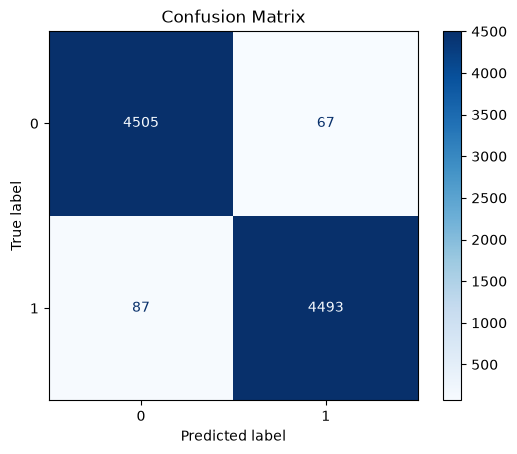

In [10]:
cm = confusion_matrix(y_test, prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [11]:
from sklearn.model_selection import cross_val_score

In [12]:
print(type(best_model))

<class 'sklearn.svm._classes.LinearSVC'>


In [13]:
scores = cross_val_score(
    best_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(scores)

[0.98224286 0.98210627 0.98606748 0.98292583 0.98237946]


In [14]:
print("Mean Accuracy :", scores.mean())

print("Standard Deviation :", scores.std())

Mean Accuracy : 0.9831443791831717
Standard Deviation : 0.0014878020821407097


In [15]:
misclassified = np.where(prediction != y_test)[0]

print("Number of Misclassified Samples :", len(misclassified))

Number of Misclassified Samples : 154


In [16]:
for i in misclassified[:10]:

    print("="*80)

    print("Actual :", y_test.iloc[i])

    print("Predicted :", prediction[i])

    print()

Actual : 1
Predicted : 0

Actual : 0
Predicted : 1

Actual : 0
Predicted : 1

Actual : 1
Predicted : 0

Actual : 1
Predicted : 0

Actual : 0
Predicted : 1

Actual : 0
Predicted : 1

Actual : 0
Predicted : 1

Actual : 1
Predicted : 0

Actual : 1
Predicted : 0



In [17]:
joblib.dump(
    best_model,
    "models/final_fake_news_model.pkl"
)

['models/final_fake_news_model.pkl']

Four machine learning algorithms were evaluated.
Linear SVM achieved the highest accuracy (98.32%).
Cross-validation confirmed that the model generalizes well.
The final model was saved for deployment.
The next phase is building a web application for real-time fake news detection.